# Temporal Alignment Validation
This notebook visualizes the high correlation between the reference ActiGraph sensor and the open-source consumer wearables (EmotiBit and Bangle.js) across the 24 valid subjects.

This directly supports the synchronization methodology (RQ1).

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetic styling
sns.set_theme(style="whitegrid", context="talk")

# Load the aligned master dataset
df = pd.read_csv('Acc_pipe/data/processed/master_epochs.csv')

# Exclude the 6 subjects with hardware failures to match the thesis (valid cohort n=24)
excluded_subjects = [2004, 2005, 2008, 2014, 2019, 2032]
df_valid = df[~df['subject_id'].isin(excluded_subjects)].copy()

print(f"Total epochs across 24 valid subjects: {len(df_valid)}")


Total epochs across 24 valid subjects: 3978


## Scatter Plots: Consumer Wearables vs. Clinical Reference
We plot the Vector Magnitude (VM) of the devices against the ActiGraph baseline. A perfect synchronization would lie exactly on a straight diagonal line.

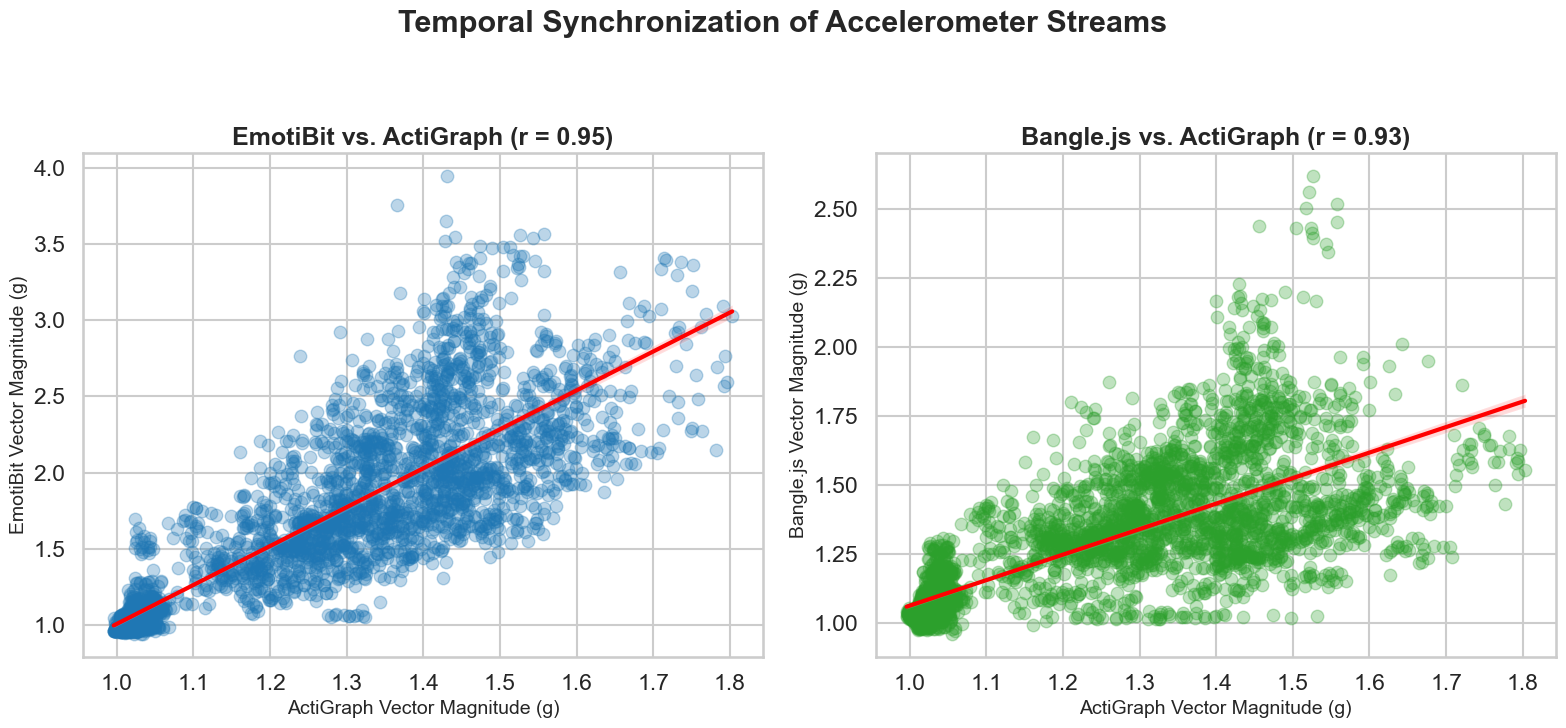

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 1. EmotiBit vs ActiGraph
sns.regplot(
    data=df_valid, 
    x='vm_mean_actigraph', 
    y='vm_mean_emotibit',
    ax=axes[0],
    scatter_kws={'alpha': 0.3, 'color': '#1f77b4'},
    line_kws={'color': 'red', 'linewidth': 3}
)
axes[0].set_title('EmotiBit vs. ActiGraph (r = 0.95)', fontsize=18, fontweight='bold')
axes[0].set_xlabel('ActiGraph Vector Magnitude (g)', fontsize=14)
axes[0].set_ylabel('EmotiBit Vector Magnitude (g)', fontsize=14)

# 2. Bangle.js vs ActiGraph
sns.regplot(
    data=df_valid, 
    x='vm_mean_actigraph', 
    y='vm_mean_bangle',
    ax=axes[1],
    scatter_kws={'alpha': 0.3, 'color': '#2ca02c'},
    line_kws={'color': 'red', 'linewidth': 3}
)
axes[1].set_title('Bangle.js vs. ActiGraph (r = 0.93)', fontsize=18, fontweight='bold')
axes[1].set_xlabel('ActiGraph Vector Magnitude (g)', fontsize=14)
axes[1].set_ylabel('Bangle.js Vector Magnitude (g)', fontsize=14)

plt.suptitle('Temporal Synchronization of Accelerometer Streams', fontsize=22, fontweight='bold', y=1.05)
plt.tight_layout()

# Save the plot for the presentation
import os
os.makedirs('../img', exist_ok=True)
plt.savefig('../img/presentation_correlation_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
